阶段1：构造模型

在票价确定的前提下，预测各航段的客流量（已完成）。

阶段2：解析过程

根据客流信息分配舱位，以确定总收益。
客舱分为两类：短途类（AB或BC，称为S类）和长途类（AC，称为L类），总容量为C。

根据是否满座进行分类：

若不满座（S+L≤C），则按S、L和C的预测比例分配舱位，以实现收益最大化。
若满座（S+L>C），则需根据销售量变化预测进行取舍，并作如下判断：
若票价AB+BC>AC，则优先将舱位拆分为AB和BC段销售，S的值取min(AB, BC)，其余舱位分配给L。
若票价AB+BC<AC，则优先分配舱位给AC段，剩余舱位分配给AB和BC段。

阶段3：求总收益最大值

以票价为自变量，总收益为因变量，绘制总收益曲线，并求出总收益的最大值。

## 加载CSV文件

In [1]:
import pandas as pd
import numpy as np

# 读取CSV文件
# /Users/zhanyu/code/data-hh/海航系销售结果数据
df = pd.read_csv('../../data-hh/海航系销售结果数据/mid_flt_allmkt_segment_result_sale_tmp_202410221653.csv')

# 显示前两行数据以确保正确加载
print(df.shape)
print(df.head(5))

(978515, 15)
     flt_date                    segment        flt_no bd_type  dep_time  cap  \
0  2023-01-01  gK3uAaRHrOs=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  18:00:00    0   
1  2023-01-01  TtI1YSy7OME=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  20:00:00    0   
2  2023-01-01  gK3uAaRHrOs=-TtI1YSy7OME=  jpD8rZ2KA6Y=      未知  18:00:00    0   
3  2023-01-01  5t+HPO9Mu/w=-X5e5r3CS4OA=  izjfHOxAho4=      窄体  13:25:00  132   
4  2023-01-01  X5e5r3CS4OA=-5t+HPO9Mu/w=  nKALH9OikCM=      窄体  16:15:00  132   

  aircraft  legs  leg_no  duration   tkt_rev  pax             a             b  \
0      NaN     3       3      0.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=   
1      NaN     3       2      3.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=   
2      NaN     3       1      1.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=   
3      319     1       1      1.70  223630.0  127  5t+HPO9Mu/w=  X5e5r3CS4OA=   
4      319     1       1      2.28   76854.0   60  X5e5r3CS4OA=  5t+HPO9Mu/w=   

             

## 拆分 flt_date 为 year, month, day, weekday

In [2]:
# 将 'flt_date' 列转换为 datetime 格式
df['flt_date'] = pd.to_datetime(df['flt_date'])

# 提取年、月、日和星期几
df['year'] = df['flt_date'].dt.year
df['month'] = df['flt_date'].dt.month
df['day'] = df['flt_date'].dt.day
df['weekday'] = df['flt_date'].dt.weekday  # 0 = Monday, 6 = Sunday

# 删除原始的 'flt_date' 字段
df = df.drop(columns=['flt_date'])

# 查看结果
print(df.head(5))

                     segment        flt_no bd_type  dep_time  cap aircraft  \
0  gK3uAaRHrOs=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  18:00:00    0      NaN   
1  TtI1YSy7OME=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知  20:00:00    0      NaN   
2  gK3uAaRHrOs=-TtI1YSy7OME=  jpD8rZ2KA6Y=      未知  18:00:00    0      NaN   
3  5t+HPO9Mu/w=-X5e5r3CS4OA=  izjfHOxAho4=      窄体  13:25:00  132      319   
4  X5e5r3CS4OA=-5t+HPO9Mu/w=  nKALH9OikCM=      窄体  16:15:00  132      319   

   legs  leg_no  duration   tkt_rev  pax             a             b  \
0     3       3      0.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=   
1     3       2      3.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=   
2     3       1      1.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=   
3     1       1      1.70  223630.0  127  5t+HPO9Mu/w=  X5e5r3CS4OA=   
4     1       1      2.28   76854.0   60  X5e5r3CS4OA=  5t+HPO9Mu/w=   

              c  year  month  day  weekday  
0  5t+HPO9Mu/w=  2023      1    1        6  
1  5t+HP

## 拆分 dep_time 为 hour, minute, second

In [3]:
# 拆分 'dep_time' 字段
df[['hour', 'minute', 'second']] = df['dep_time'].str.split(':', expand=True)

# 将拆分的结果转换为整数
df['hour'] = df['hour'].astype(int)
df['minute'] = df['minute'].astype(int)
df['second'] = df['second'].astype(int)

# 删除原始的 'dep_time' 字段
df = df.drop(columns=['dep_time'])

# 查看结果
print(df.head(5))

                     segment        flt_no bd_type  cap aircraft  legs  \
0  gK3uAaRHrOs=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知    0      NaN     3   
1  TtI1YSy7OME=-5t+HPO9Mu/w=  jpD8rZ2KA6Y=      未知    0      NaN     3   
2  gK3uAaRHrOs=-TtI1YSy7OME=  jpD8rZ2KA6Y=      未知    0      NaN     3   
3  5t+HPO9Mu/w=-X5e5r3CS4OA=  izjfHOxAho4=      窄体  132      319     1   
4  X5e5r3CS4OA=-5t+HPO9Mu/w=  nKALH9OikCM=      窄体  132      319     1   

   leg_no  duration   tkt_rev  pax             a             b             c  \
0       3      0.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=  5t+HPO9Mu/w=   
1       2      3.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=  5t+HPO9Mu/w=   
2       1      1.00       0.0    0  gK3uAaRHrOs=  TtI1YSy7OME=  5t+HPO9Mu/w=   
3       1      1.70  223630.0  127  5t+HPO9Mu/w=  X5e5r3CS4OA=           NaN   
4       1      2.28   76854.0   60  X5e5r3CS4OA=  5t+HPO9Mu/w=           NaN   

   year  month  day  weekday  hour  minute  second  
0  2023      1    1  

## 拆分 segment 为 from 和 to

In [4]:
# 拆分 'segment' 字段为 'from' 和 'to'
df[['from', 'to']] = df['segment'].str.split('-', expand=True)

# 删除原始的 'segment' 字段
df = df.drop(columns=['segment'])

# 查看结果
print(df.head(10))

         flt_no bd_type  cap aircraft  legs  leg_no  duration   tkt_rev  pax  \
0  jpD8rZ2KA6Y=      未知    0      NaN     3       3      0.00       0.0    0   
1  jpD8rZ2KA6Y=      未知    0      NaN     3       2      3.00       0.0    0   
2  jpD8rZ2KA6Y=      未知    0      NaN     3       1      1.00       0.0    0   
3  izjfHOxAho4=      窄体  132      319     1       1      1.70  223630.0  127   
4  nKALH9OikCM=      窄体  132      319     1       1      2.28   76854.0   60   
5  IZlQuHVyuHM=      窄体  164      320     1       1      1.63  153536.0  161   
6  JuuFTkIMLPM=      窄体  164      320     1       1      1.55   26710.0   57   
7  vuYlZdVahdQ=      窄体  194      321     1       1      1.70  171547.0  191   
8  gK2REUaqyqE=      窄体  194      321     1       1      1.62   17550.0   29   
9  GghRBqSDm4g=      窄体  164      320     1       1      1.55  138829.0  152   

              a  ...             c  year  month  day  weekday  hour  minute  \
0  gK3uAaRHrOs=  ...  5t+HPO9Mu/w=  2023

## 删除pax异常的行

In [5]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['pax'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['pax'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

978515
缺失值的行数: 0
为0的行数: 26856


In [6]:
# 删除 'pax' 字段为缺失值或为0的行
df = df.dropna(subset=['pax'])  # 删除pax列中的缺失值行
df = df[df['pax'] != 0]  # 删除pax列中为0的行

# 查看删除后的DataFrame行数
num_rows_after_cleanup = df.shape[0]
print(f"删除缺失值或为0的行后，DataFrame一共有 {num_rows_after_cleanup} 行")

删除缺失值或为0的行后，DataFrame一共有 951659 行


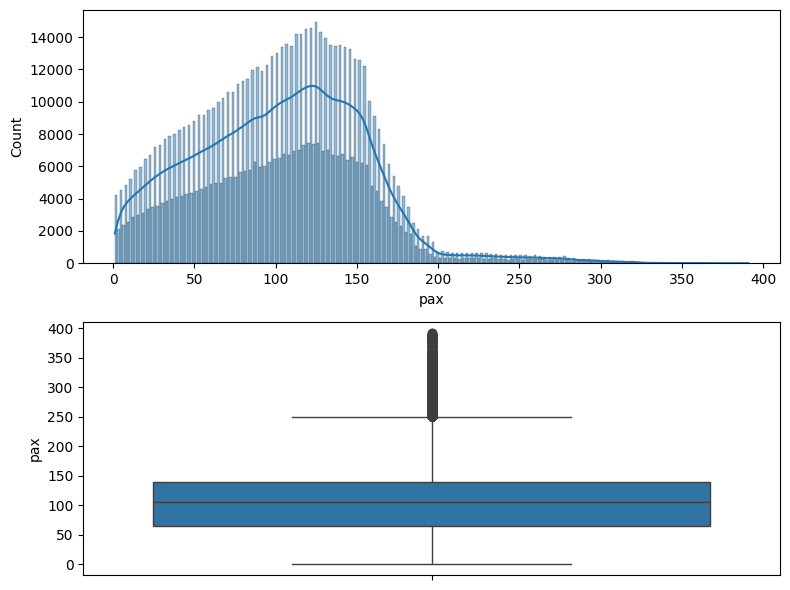

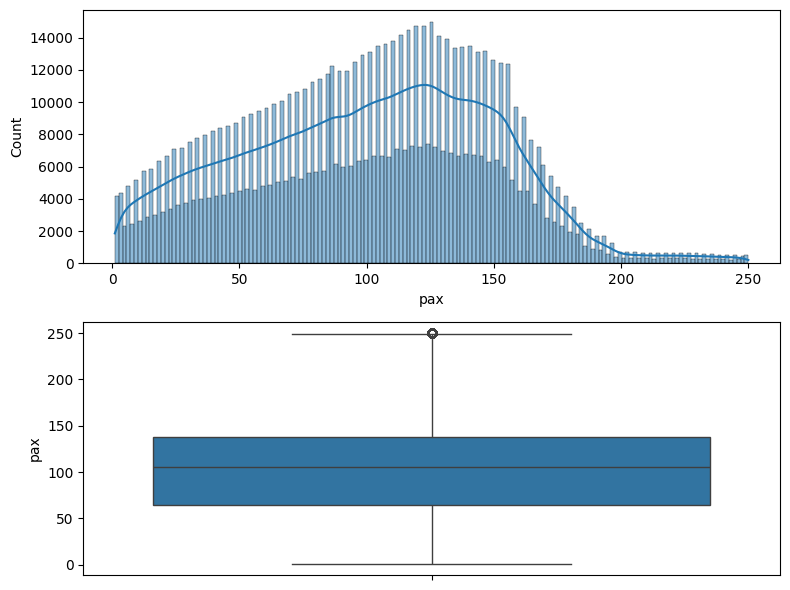

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def remove_outliers(data, col):
    """删除指定列中的异常值"""
    Q1 = data[col].quantile(0.25)  # 第1四分位数
    Q3 = data[col].quantile(0.75)  # 第3四分位数
    IQR = Q3 - Q1  # 四分位距
    lower_bound = Q1 - 1.5 * IQR  # 下限
    upper_bound = Q3 + 1.5 * IQR  # 上限
    
    # 筛选出范围内的数据
    filtered_data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return filtered_data

def plot(data, col):
    """绘制指定列的分布图和箱型图"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))
    sns.histplot(data[col], kde=True, ax=ax1)  # 替换 distplot 为 histplot
    sns.boxplot(data[col], ax=ax2)
    plt.tight_layout()
    plt.show()

# 绘制过滤后的数据分布图和箱型图
plot(df, 'pax')
# 示例数据框
# 假设 df 是你的数据框
# 删除 pax 列中的异常值
df = remove_outliers(df, 'pax')

# 绘制过滤后的数据分布图和箱型图
plot(df, 'pax')


In [8]:
# 删除 pax 小于 20 的行
df = df[df['pax'] >= 20]

## 处理aircraft

In [9]:
# 查看 'cap' 列中每个元素的数据类型
print(df['aircraft'].apply(type).value_counts())

aircraft
<class 'str'>      890879
<class 'float'>         8
Name: count, dtype: int64


In [10]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['aircraft'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['aircraft'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

890887
缺失值的行数: 8
为0的行数: 0


In [11]:
# 将 cap 列转换为 Pandas 的 Int64 类型，这种类型支持 NaN 值
# 将 'aircraft' 列转换为字符串类型
# 用 'Unknown' 填充 NaN 值
df['aircraft'] = df['aircraft'].fillna('Unknown')
df['aircraft'] = df['aircraft'].astype(str)

In [12]:
# 查看 'cap' 列中每个元素的数据类型
print(df['aircraft'].apply(type).value_counts())

aircraft
<class 'str'>    890887
Name: count, dtype: int64


## 处理cap

In [13]:
# 查看 'cap' 列中每个元素的数据类型
print(df['cap'].apply(type).value_counts())

cap
<class 'int'>    890887
Name: count, dtype: int64


In [14]:
# 统计 'pax' 字段中缺失值的行数
missing_pax = df[df['cap'].isna()]

# 统计 'pax' 字段中0值的行数
zero_pax = df[df['cap'] == 0]

# 输出统计结果
num_missing = missing_pax.shape[0]
num_zero = zero_pax.shape[0]

print(df.shape[0])
print(f"缺失值的行数: {num_missing}")
print(f"为0的行数: {num_zero}")

# 将 'cap' 字段中为0的值修改为 NaN
df.loc[df['cap'] == 0, 'cap'] = np.nan

# 将 'cap' 字段转换为字符串类型
df['cap'] = df['cap'].astype(str)



890887
缺失值的行数: 0
为0的行数: 93647


In [15]:
# 查看 'cap' 列中每个元素的数据类型
print(df['cap'].apply(type).value_counts())
print(df['aircraft'].apply(type).value_counts())

cap
<class 'str'>    890887
Name: count, dtype: int64
aircraft
<class 'str'>    890887
Name: count, dtype: int64


## 处理duration（待做）

In [16]:
# 将 'duration' 列中值为 0 的部分替换为 NaN
df.loc[df['duration'] == 0, 'duration'] = np.nan

## 处理tkt_rev

有一些异常行的tkt_rev为0，pax却不为0

In [17]:
# 统计 'unit_price' 列中为 0 的行数
zero_count = (df['tkt_rev'] == 0).sum()

# 统计 'unit_price' 列中为 NaN 的行数
nan_count = df['tkt_rev'].isna().sum()

# 输出结果
print(f"tkt_rev 列中为 0 的行数: {zero_count}")
print(f"tkt_rev 列中为 NaN 的行数: {nan_count}")

tkt_rev 列中为 0 的行数: 47
tkt_rev 列中为 NaN 的行数: 0


In [18]:
df = df[df['tkt_rev'] != 0]

# 计算单价 'unit_price'，即 tkt_rev 除以 pax
df['unit_price'] = df['tkt_rev'] / df['pax']

# 删除 'tkt_rev' 列
df = df.drop(columns=['tkt_rev'])

## 保存文件

In [19]:
# 保存处理后的数据到新的CSV文件
df.to_csv('../../data-hh/my/202410221653-processed.csv', index=False)

In [20]:
# 输出 'unit_price' 列中值为 0 的所有行
zero_rows = df[df['unit_price'] == 0]

# 查看结果
print(zero_rows)


Empty DataFrame
Columns: [flt_no, bd_type, cap, aircraft, legs, leg_no, duration, pax, a, b, c, year, month, day, weekday, hour, minute, second, from, to, unit_price]
Index: []

[0 rows x 21 columns]
